# Feature Selection

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import json

features = pd.read_csv('data/features.csv')

# drop any rows with ai_exposure_score = 0
features = features[features['AI Exposure Score (0-0.29)'] != 0]
# drop any rows with NaN values
features = features.dropna()

print("Number of rows:",len(features))

# split into features and target
X, Y = features.drop(columns=['AI Exposure Score (0-0.29)']), features['AI Exposure Score (0-0.29)']

# exclude FIPS from features
X = X.drop(columns=['FIPS'])

Number of rows: 80679


## Correlation Filtering

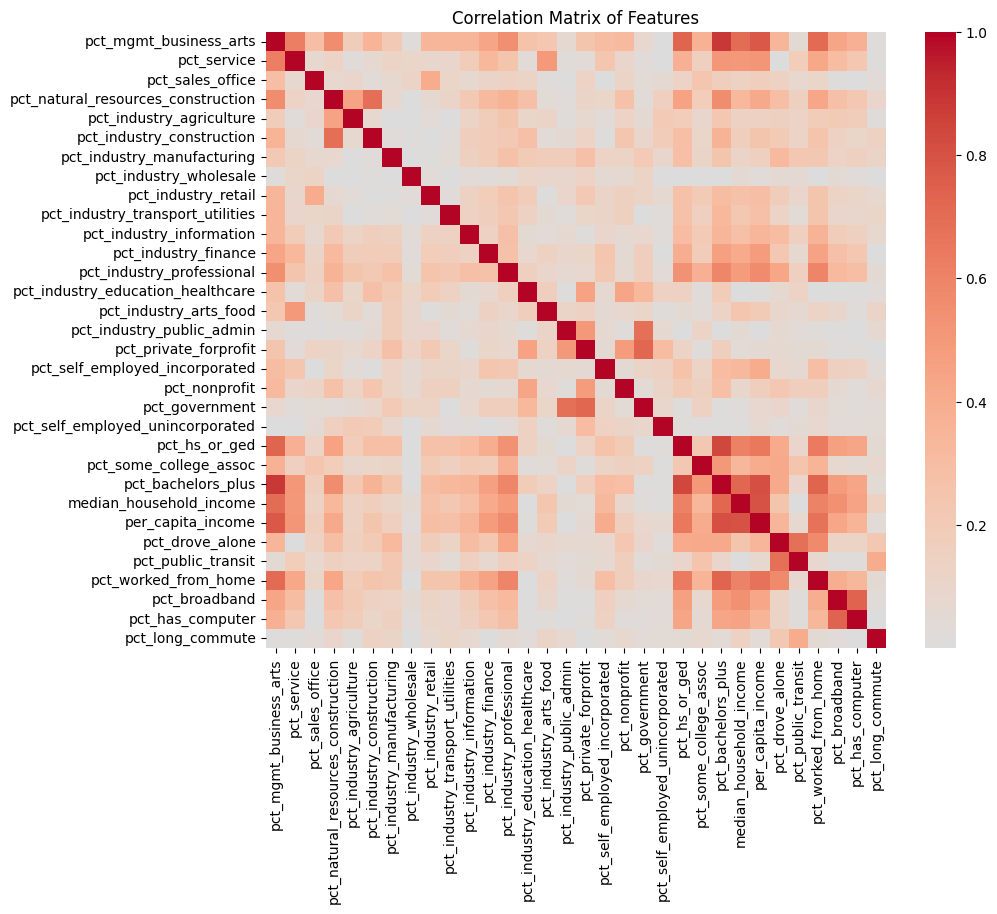

In [15]:
correlation_matrix = X.corr().abs()
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features')
plt.show()

In [16]:
print('Original number of features:', len(X.columns))

for col in X.columns:
    for col2 in X.columns:
        if col != col2:
            if upper.loc[col, col2] > 0.80:
                print("Highly correlated features:", col, ",", col2)


Original number of features: 32
Highly correlated features: pct_mgmt_business_arts , pct_bachelors_plus
Highly correlated features: pct_hs_or_ged , pct_bachelors_plus
Highly correlated features: pct_bachelors_plus , per_capita_income
Highly correlated features: median_household_income , per_capita_income


In [17]:
drop_col = ["pct_mgmt_business_arts", "pct_hs_or_ged", "median_household_income"]
X = X.drop(columns=drop_col)
print('Number of features after correlation filtering:', len(X.columns))

Number of features after correlation filtering: 29


## Mutual Information

In [18]:
X_scaled = StandardScaler().fit_transform(X)

mi_scores = mutual_info_regression(
    X_scaled,
    Y,
    random_state=42,
    n_neighbors=5
)

df_mi = pd.DataFrame({
    "feature": X.columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

k = 10

display(df_mi.head(k))

,feature,mutual_information
21,pct_bachelors_plus,0.025902
22,per_capita_income,0.022420
2,pct_natural_resources_construction,0.020218
23,pct_drove_alone,0.019443
25,pct_worked_from_home,0.018966
11,pct_industry_professional,0.016741
3,pct_industry_agriculture,0.015132
26,pct_broadband,0.013915
27,pct_has_computer,0.012821
24,pct_public_transit,0.012430


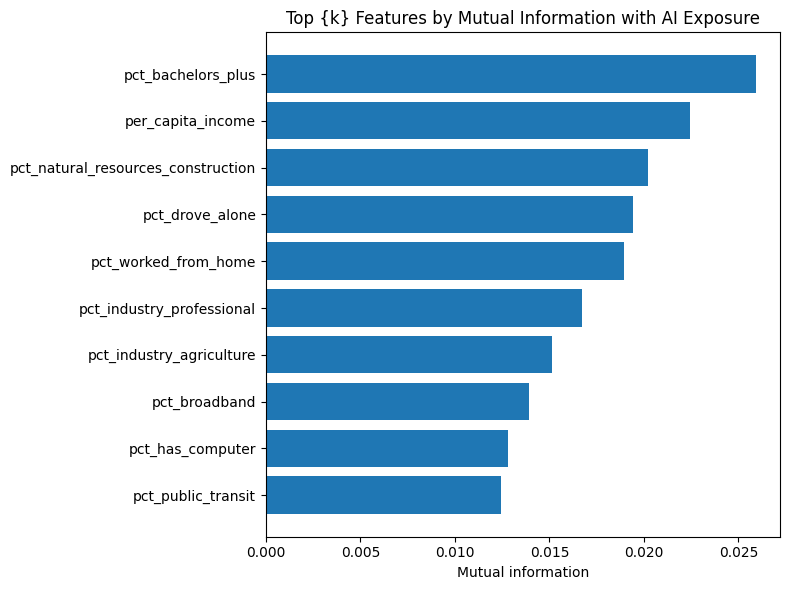

In [19]:
top_k_mi = df_mi.head(k).sort_values("mutual_information", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_k_mi["feature"], top_k_mi["mutual_information"])
plt.xlabel("Mutual information")
plt.title("Top {k} Features by Mutual Information with AI Exposure")
plt.tight_layout()
plt.show()

In [20]:
feature_groups = {
    "occupation": [
        "pct_service",
        "pct_sales_office",
        "pct_natural_resources_construction",
    ],

    "industry": [
        "pct_industry_agriculture",
        "pct_industry_construction",
        "pct_industry_manufacturing",
        "pct_industry_wholesale",
        "pct_industry_retail",
        "pct_industry_transport_utilities",
        "pct_industry_information",
        "pct_industry_finance",
        "pct_industry_professional",
        "pct_industry_education_healthcare",
        "pct_industry_arts_food",
        "pct_industry_public_admin",
    ],

    "employment_type": [
        "pct_private_forprofit",
        "pct_self_employed_incorporated",
        "pct_nonprofit",
        "pct_government",
        "pct_self_employed_unincorporated",
    ],

    "education_income": [
        "pct_some_college_assoc",
        "pct_bachelors_plus",
        "per_capita_income",
    ],

    "commute": [
        "pct_drove_alone",
        "pct_public_transit",
        "pct_worked_from_home",
        "pct_long_commute",
    ],

    "digital_access": [
        "pct_broadband",
        "pct_has_computer",
    ],
}

# save feature groups to json
feature_groups = {
    group: [c for c in cols if c in X.columns]
    for group, cols in feature_groups.items()
}
with open("feature_groups.json", "w") as f:
    json.dump(feature_groups, f, indent=4)

In [21]:
category_mi = []

for group, cols in feature_groups.items():
    valid_cols = [c for c in cols if c in df_mi["feature"].values]
    group_scores = df_mi.loc[
        df_mi["feature"].isin(valid_cols),
        "mutual_information"
    ]
    category_mi.append({
        "feature_group": group,
        "mean_mi": group_scores.mean(),
        "top_feature": df_mi[df_mi["feature"].isin(valid_cols)].iloc[0]["feature"]
    })

category_mi_df = (
    pd.DataFrame(category_mi)
    .sort_values("mean_mi", ascending=False)
)

display(category_mi_df)

,feature_group,mean_mi,top_feature
3,education_income,0.019666,pct_bachelors_plus
5,digital_access,0.013368,pct_broadband
4,commute,0.012846,pct_drove_alone
0,occupation,0.008154,pct_natural_resources_construction
1,industry,0.006769,pct_industry_professional
2,employment_type,0.003386,pct_government


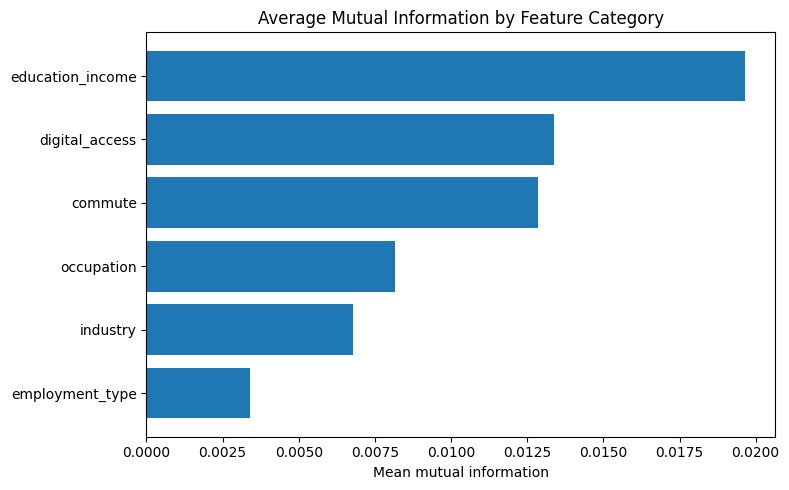

In [22]:
plot_df = category_mi_df.sort_values("mean_mi")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_group"], plot_df["mean_mi"])
plt.xlabel("Mean mutual information")
plt.title("Average Mutual Information by Feature Category")
plt.tight_layout()
plt.show()

## PCA

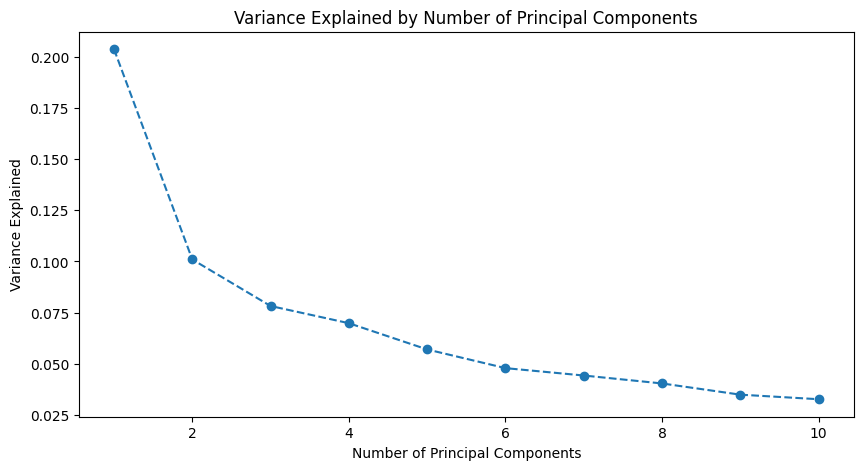

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained) + 1), explained, marker='o', linestyle='--')
plt.title('Variance Explained by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Explained')
plt.show()


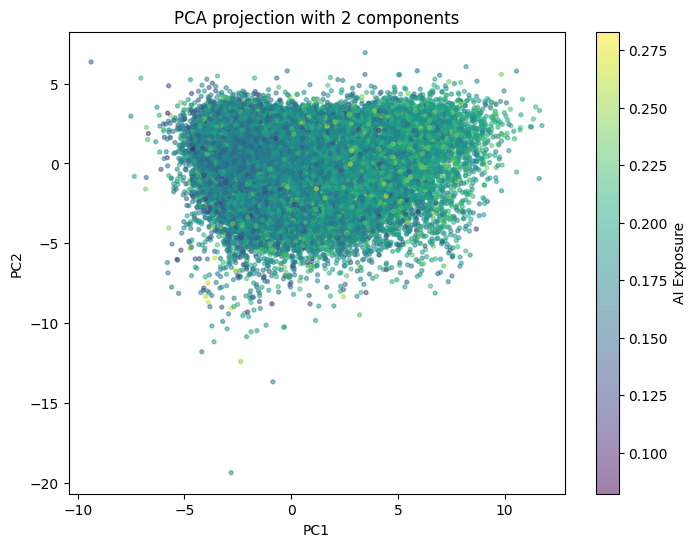

In [24]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=Y,
    s=8,
    alpha=0.5
)
plt.colorbar(sc, label="AI Exposure")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection with 2 components")
plt.show()

In [25]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"]
)

display(loadings["PC1"].abs().sort_values(ascending=False).head(10))
display(loadings["PC2"].abs().sort_values(ascending=False).head(10))

pct_bachelors_plus                    0.377174
per_capita_income                     0.344466
pct_worked_from_home                  0.339356
pct_industry_professional             0.287967
pct_natural_resources_construction    0.253692
pct_drove_alone                       0.241042
pct_industry_finance                  0.227830
pct_broadband                         0.225033
pct_some_college_assoc                0.209565
pct_has_computer                      0.200982
Name: PC1, dtype: float64

pct_private_forprofit                0.509601
pct_government                       0.463733
pct_industry_education_healthcare    0.372860
pct_industry_public_admin            0.347345
pct_nonprofit                        0.255908
pct_industry_manufacturing           0.165016
pct_industry_construction            0.137546
pct_industry_finance                 0.137020
pct_self_employed_incorporated       0.134015
pct_industry_wholesale               0.130179
Name: PC2, dtype: float64

In [26]:
# save new df after feature selection
model_df = X.copy()
model_df["AI_exposure"] = Y

model_df.to_csv("data/model_df.csv", index=False)